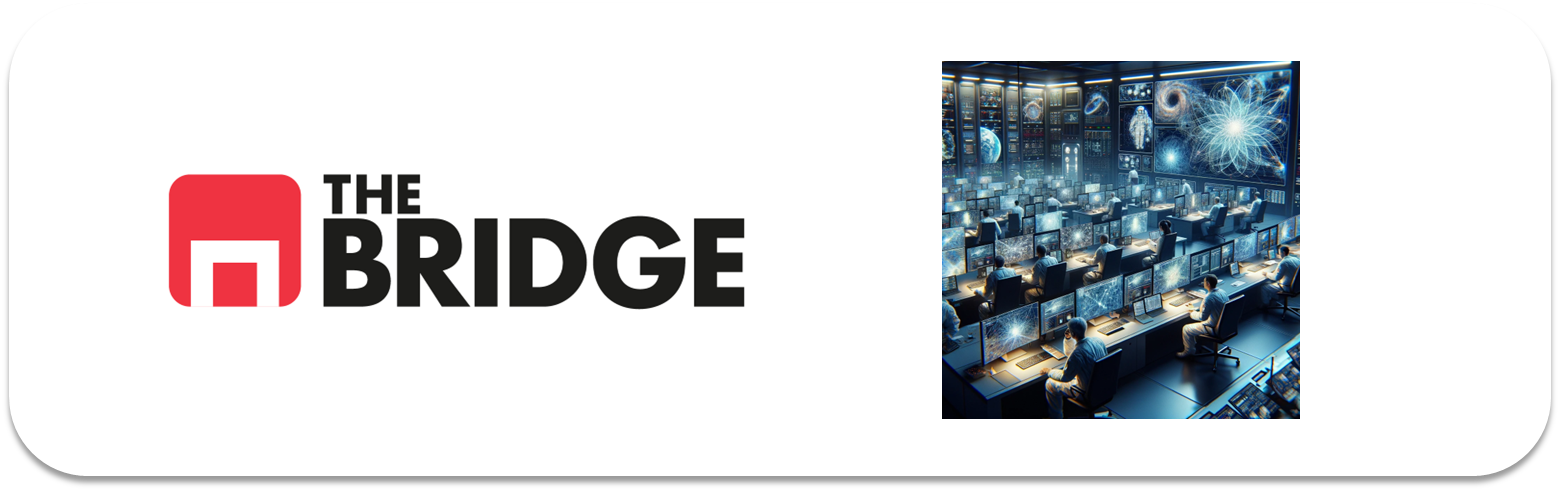

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [26]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix

In [27]:
# Ruta a los datos de la practica anterior
RUTA_DATOS = "../../Unidad_01_CNN_Redes_Convolucionales/03_Practica_Obligatoria/data"

# MobileNetV2 necesita minimo 96x96 (con 32x32 no funciona)
TAM = (96, 96)

# Funcion que lee las imagenes de una lista de directorios y las adapta al tamano indicado
def cargar_imagenes(directorios, tam=TAM):
    X, y, nombres = [], [], []

    for directorio in directorios:
        for archivo in sorted(os.listdir(directorio)):
            if not archivo.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            # La clase esta en el nombre del archivo: cat.1234.jpg / dog.1234.jpg
            clase = archivo.split(".")[0].lower()
            if clase not in ("cat", "dog"):
                continue

            ruta = os.path.join(directorio, archivo)
            img = Image.open(ruta).convert("RGB").resize(tam)

            X.append(np.array(img))
            y.append(0 if clase == "cat" else 1)   # 0 = gato, 1 = perro
            nombres.append(archivo)

    return np.array(X), np.array(y), nombres

In [28]:
# Cargamos train (los cuatro directorios) y test
directorios_train = [f"{RUTA_DATOS}/github_train_{i}" for i in range(4)]
directorio_test = [f"{RUTA_DATOS}/github_test"]

X_train, y_train, nombres_train = cargar_imagenes(directorios_train)
X_test, y_test, nombres_test = cargar_imagenes(directorio_test)

clases = ["gato", "perro"]

print("Train:", X_train.shape, " -> gatos:", (y_train == 0).sum(), " perros:", (y_train == 1).sum())
print("Test :", X_test.shape, " -> gatos:", (y_test == 0).sum(), " perros:", (y_test == 1).sum())

Train: (4000, 96, 96, 3)  -> gatos: 2000  perros: 2000
Test : (1000, 96, 96, 3)  -> gatos: 500  perros: 500


In [29]:
# Barajamos el train (los directorios estan separados por clase)
rng = np.random.RandomState(42)
indices = rng.permutation(len(X_train))

X_train = X_train[indices]
y_train = y_train[indices]
nombres_train = [nombres_train[i] for i in indices]

print("Primeras 15 etiquetas tras barajar:", y_train[:15])

Primeras 15 etiquetas tras barajar: [0 1 0 1 1 0 0 0 0 0 1 1 0 0 1]


In [30]:
# Funciones de visualizacion (copiadas de la practica anterior)
def mostrar_imagenes(imagenes, etiquetas, n=10, predicciones=None, cols=5, titulo=None):
    filas = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 2, filas * 2.3))

    for i in range(n):
        plt.subplot(filas, cols, i + 1)
        plt.imshow(imagenes[i].astype("uint8"))
        plt.axis("off")

        if predicciones is None:
            plt.title(clases[etiquetas[i]], fontsize=9)
        else:
            color = "green" if predicciones[i] == etiquetas[i] else "red"
            plt.title(f"pred: {clases[predicciones[i]]}\nreal: {clases[etiquetas[i]]}",
                      fontsize=8, color=color)

    if titulo:
        plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()


def pintar_historial(history, titulo="Historial de entrenamiento"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="validacion")
    axes[0].set_title("Perdida (loss)")
    axes[0].set_xlabel("Epoca")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="validacion")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoca")
    axes[1].legend()

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()


# Funcion para evaluar un modelo: accuracy, report y matriz de confusion
def evaluar_modelo(model, X, y, titulo="Modelo"):
    loss, acc = model.evaluate(X, y, verbose=0)
    prob_perro = model.predict(X, verbose=0).ravel()
    pred = (prob_perro >= 0.5).astype(int)

    print(f"=== {titulo} ===")
    print("Accuracy en test:", round(acc, 3))
    print("\nClassification report\n")
    print(classification_report(y, pred, target_names=clases, zero_division=0))

    cm = confusion_matrix(y, pred)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
                xticklabels=clases, yticklabels=clases)
    plt.xlabel("Prediccion")
    plt.ylabel("Real")
    plt.title(f"Matriz de confusion - {titulo}")
    plt.tight_layout()
    plt.show()

    return acc, pred, prob_perro

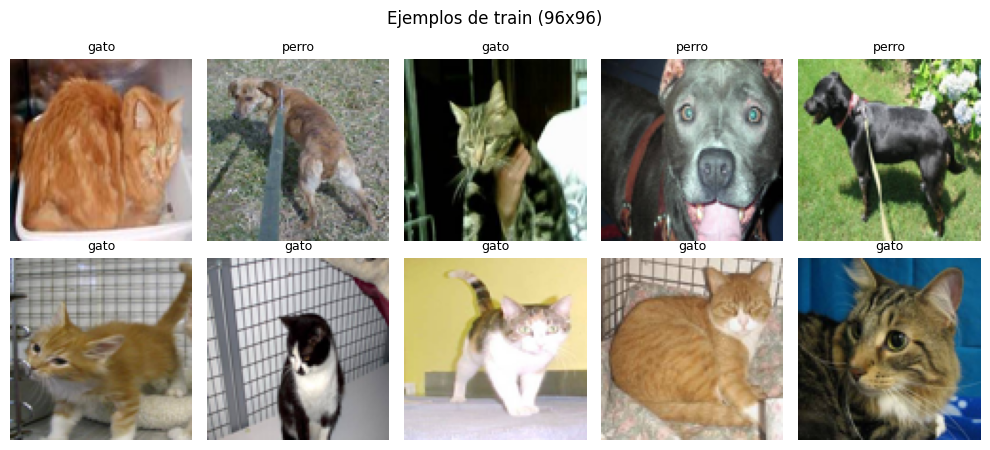

In [31]:
# Visualizamos unas cuantas imagenes (ahora a 96x96, se ven bastante mejor que a 32x32)
mostrar_imagenes(X_train, y_train, n=10, titulo="Ejemplos de train (96x96)")

In [32]:
# Preprocesado especifico de MobileNetV2 (lleva las imagenes al rango [-1, 1])
preprocess = keras.applications.mobilenet_v2.preprocess_input

X_train_prep = preprocess(X_train.astype("float32").copy())
X_test_prep = preprocess(X_test.astype("float32").copy())

print("Rango tras preprocess_input:", X_train_prep.min(), "a", X_train_prep.max())

Rango tras preprocess_input: -1.0 a 1.0


In [33]:
# Cargamos MobileNetV2 preentrenado en ImageNet, sin la capa de clasificacion
base_model = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3),
)

print("Capas de la base:", len(base_model.layers))
print("Parametros de la base:", f"{base_model.count_params():,}")

Capas de la base: 154
Parametros de la base: 2,257,984


In [34]:
# Congelamos la base: solo se entrena la cabeza
base_model.trainable = False

# Cabeza: 2 densas ocultas + salida
modelo_tl = keras.Sequential([
    keras.layers.Input(shape=(96, 96, 3)),
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
], name="transfer_learning")

modelo_tl.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

modelo_tl.summary()

Model: "transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,273 (9.27 MB)

 Trainable params: 172,289 (673.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [35]:
# Entrenamos solo la cabeza
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

t0 = time.time()
history_tl = modelo_tl.fit(
    X_train_prep, y_train,
    epochs=30,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)
tiempo_tl = time.time() - t0

print("\nEpocas entrenadas:", len(history_tl.history["loss"]))
print("Tiempo de entrenamiento:", round(tiempo_tl, 1), "s")

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.9347 - loss: 0.1674 - val_accuracy: 0.9525 - val_loss: 0.1262
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9706 - loss: 0.0817 - val_accuracy: 0.9588 - val_loss: 0.1114
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9812 - loss: 0.0540 - val_accuracy: 0.9650 - val_loss: 0.1087
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.9837 - loss: 0.0458 - val_accuracy: 0.9600 - val_loss: 0.1219
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9934 - loss: 0.0242 - val_accuracy: 0.9638 - val_loss: 0.1414
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.9916 - loss: 0.0215 - val_accuracy: 0.9625 - val_loss: 0.1290
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.9947 - loss: 0.0151 - val_accuracy: 0.9613 - val_loss: 0.1553
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.9959 - loss: 0.0120 - val_acc

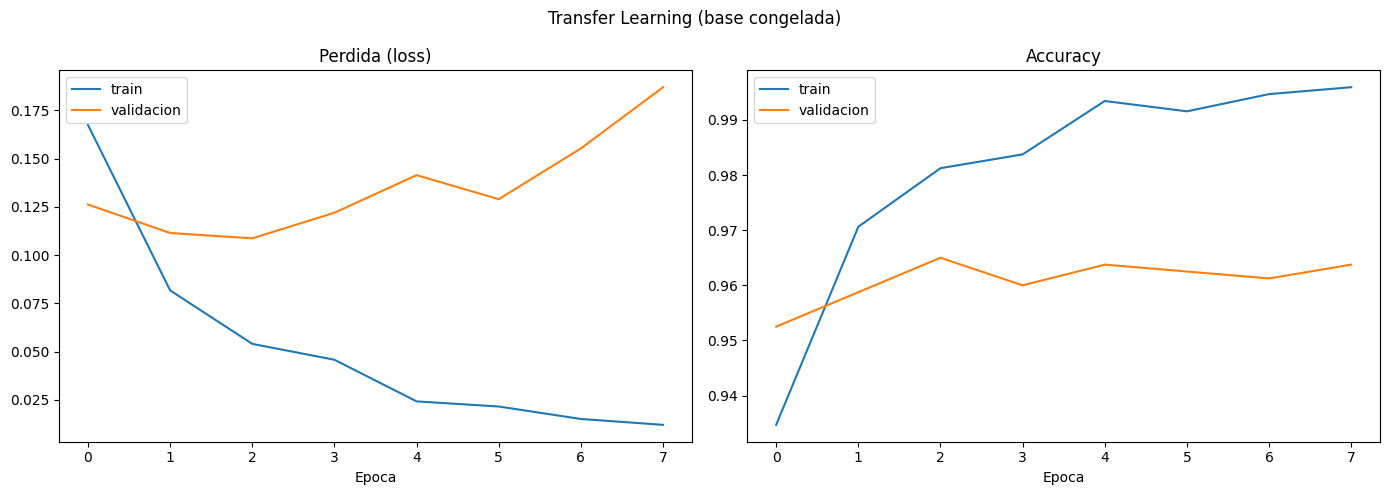

In [36]:
pintar_historial(history_tl, titulo="Transfer Learning (base congelada)")

=== Transfer Learning ===
Accuracy en test: 0.953

Classification report

              precision    recall  f1-score   support

        gato       0.97      0.93      0.95       500
       perro       0.93      0.97      0.95       500

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



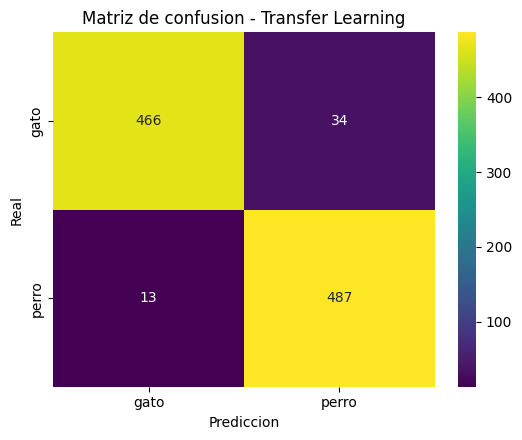

In [37]:
# Evaluacion contra test: accuracy, report y matriz de confusion
acc_tl, pred_tl, prob_tl = evaluar_modelo(modelo_tl, X_test_prep, y_test,
                                          titulo="Transfer Learning")

In [38]:
# Descongelamos la base pero solo las ultimas 30 capas
base_model.trainable = True

n_capas_congeladas = len(base_model.layers) - 30

for i, capa in enumerate(base_model.layers):
    if i < n_capas_congeladas:
        capa.trainable = False
    # Las BatchNormalization se quedan siempre congeladas
    if isinstance(capa, keras.layers.BatchNormalization):
        capa.trainable = False

entrenables = sum(1 for capa in base_model.layers if capa.trainable)
print("Capas de la base entrenables:", entrenables, "de", len(base_model.layers))

Capas de la base entrenables: 19 de 154


In [39]:
# Recompilamos con un learning rate MUY bajo (imprescindible en fine tuning)
modelo_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

early_stopping_ft = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

t0 = time.time()
history_ft = modelo_tl.fit(
    X_train_prep, y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stopping_ft],
    verbose=1
)
tiempo_ft = time.time() - t0

print("\nEpocas entrenadas:", len(history_ft.history["loss"]))
print("Tiempo de entrenamiento:", round(tiempo_ft, 1), "s")

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - accuracy: 0.9872 - loss: 0.0345 - val_accuracy: 0.9650 - val_loss: 0.1094
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9925 - loss: 0.0217 - val_accuracy: 0.9600 - val_loss: 0.1204
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.9950 - loss: 0.0147 - val_accuracy: 0.9588 - val_loss: 0.1259
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.9984 - loss: 0.0094 - val_accuracy: 0.9625 - val_loss: 0.1328
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.9987 - loss: 0.0080 - val_accuracy: 0.9638 - val_loss: 0.1326
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.9991 - loss: 0.0054 - val_accuracy: 0.9613 - val_loss: 0.1457

Epocas entrenadas: 6
Tiempo de entrenamiento: 63.5 s


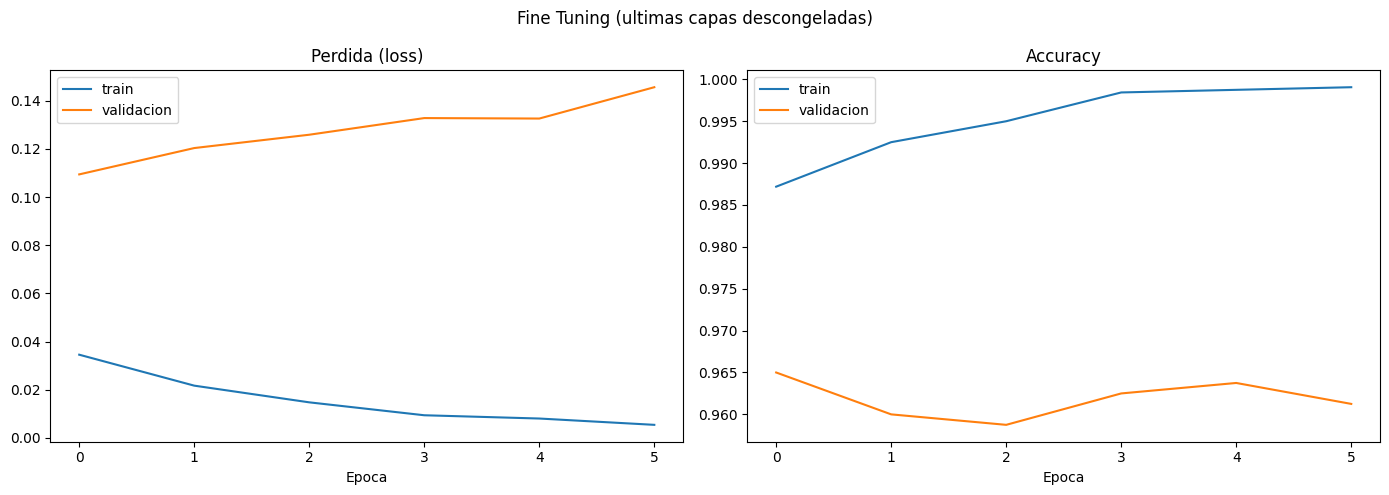

In [40]:
pintar_historial(history_ft, titulo="Fine Tuning (ultimas capas descongeladas)")

=== Fine Tuning ===
Accuracy en test: 0.966

Classification report

              precision    recall  f1-score   support

        gato       0.97      0.96      0.97       500
       perro       0.96      0.97      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



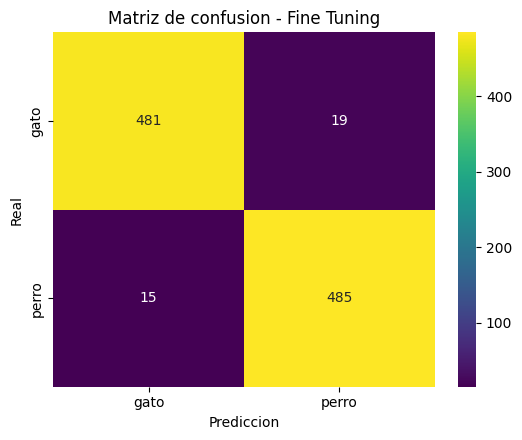

In [41]:
# Evaluacion contra test del fine tuning
acc_ft, pred_ft, prob_ft = evaluar_modelo(modelo_tl, X_test_prep, y_test,
                                          titulo="Fine Tuning")

In [17]:
# CNN ad-hoc de la practica anterior (normalizada a [0,1], como entonces)
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

modelo_cnn = keras.Sequential([
    keras.layers.Input(shape=(96, 96, 3)),
    keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation="sigmoid"),
], name="cnn_adhoc")

modelo_cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stopping_cnn = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

t0 = time.time()
history_cnn = modelo_cnn.fit(
    X_train_norm, y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stopping_cnn],
    verbose=1
)
tiempo_cnn = time.time() - t0

print("\nEpocas entrenadas:", len(history_cnn.history["loss"]))

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 137ms/step - accuracy: 0.5462 - loss: 0.6864 - val_accuracy: 0.6288 - val_loss: 0.6467
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.6456 - loss: 0.6404 - val_accuracy: 0.6725 - val_loss: 0.6172
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.6853 - loss: 0.6005 - val_accuracy: 0.6775 - val_loss: 0.5973
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.7222 - loss: 0.5583 - val_accuracy: 0.7100 - val_loss: 0.5684
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.7497 - loss: 0.5146 - val_accuracy: 0.7138 - val_loss: 0.5673
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.7809 - loss: 0.4704 - val_accuracy: 0.7375 - val_loss: 0.5526
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.7997 - loss: 0.4212 - val_accuracy: 0.7188 - val_loss: 0.5687
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step - accuracy: 0.8359 - loss: 0

=== CNN ad-hoc ===
Accuracy en test: 0.755

Classification report

              precision    recall  f1-score   support

        gato       0.75      0.77      0.76       500
       perro       0.76      0.74      0.75       500

    accuracy                           0.76      1000
   macro avg       0.76      0.76      0.75      1000
weighted avg       0.76      0.76      0.75      1000



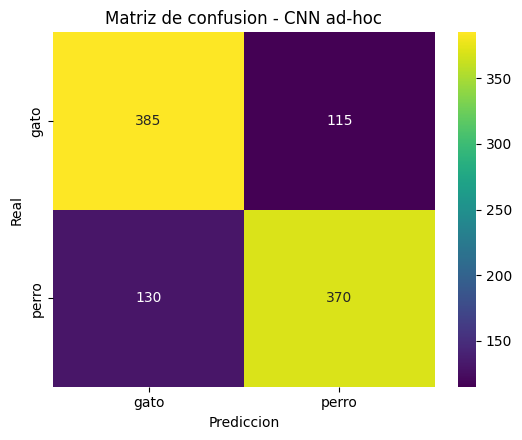

In [18]:
acc_cnn, pred_cnn, prob_cnn = evaluar_modelo(modelo_cnn, X_test_norm, y_test,
                                            titulo="CNN ad-hoc")

In [19]:
# Tabla comparativa de los tres modelos
comparacion = pd.DataFrame({
    "modelo": ["CNN ad-hoc", "Transfer Learning", "Fine Tuning"],
    "accuracy_test": [acc_cnn, acc_tl, acc_ft],
    "tiempo_entren_s": [tiempo_cnn, tiempo_tl, tiempo_ft],
    "epocas": [len(history_cnn.history["loss"]),
               len(history_tl.history["loss"]),
               len(history_ft.history["loss"])],
}).round(3)

comparacion

,modelo,accuracy_test,tiempo_entren_s,epocas
0,CNN ad-hoc,0.755,175.503,13
1,Transfer Learning,0.957,87.904,7
2,Fine Tuning,0.966,96.176,7


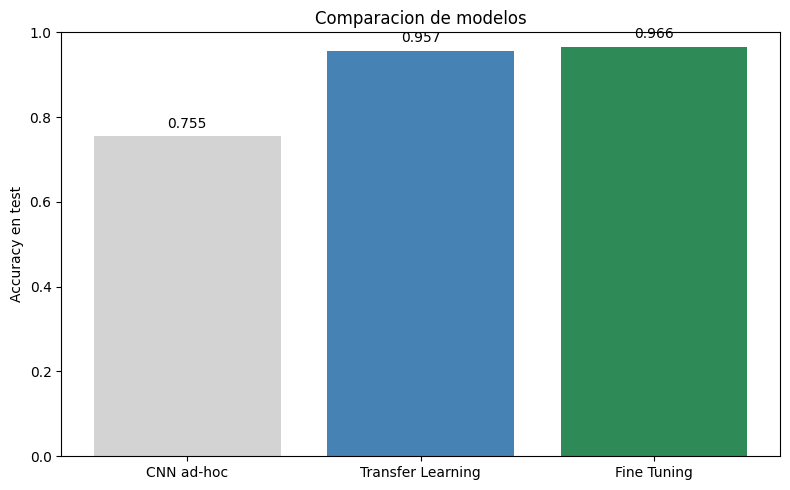

In [20]:
# Grafico comparativo de accuracy
plt.figure(figsize=(8, 5))
barras = plt.bar(comparacion["modelo"], comparacion["accuracy_test"],
                 color=["lightgray", "steelblue", "seagreen"])
plt.ylabel("Accuracy en test")
plt.ylim(0, 1)
plt.title("Comparacion de modelos")

for barra, valor in zip(barras, comparacion["accuracy_test"]):
    plt.text(barra.get_x() + barra.get_width() / 2, valor + 0.02,
             f"{valor:.3f}", ha="center")

plt.tight_layout()
plt.show()

**Comentario de la comparación:**

La diferencia es muy grande a favor de los modelos preentrenados. La CNN ad-hoc parte de cero y solo dispone de ~1000 imágenes, que es muy poco para aprender desde nada. MobileNetV2, en cambio, ya sabe detectar bordes, texturas y formas porque fue entrenado con **más de un millón de imágenes de ImageNet** (que además incluía muchas razas de perros y gatos), así que solo tiene que aprender a combinar esas características.

El **fine tuning** suele mejorar algo más que el transfer learning puro, porque adapta las últimas capas convolucionales a nuestro dominio concreto — aunque con un dataset tan pequeño la mejora puede ser pequeña y hay riesgo de sobreajuste si se descongelan demasiadas capas.

### EXTRA — Transfer learning con aumentado de imágenes

Repetimos el transfer learning generando variaciones sintéticas. Ojo a un detalle: el `preprocessing_function` del generador debe ser el **`preprocess_input` de MobileNetV2**, para que las imágenes aumentadas lleguen en el mismo rango que espera el modelo.

In [21]:
# Generador con augmentation + el preprocesado propio de MobileNetV2
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    preprocessing_function=preprocess,
)

# Separamos validacion a mano (con flow no se puede usar validation_split)
n_val = int(0.2 * len(X_train))
X_val_aug = preprocess(X_train[:n_val].astype("float32").copy())
y_val_aug = y_train[:n_val]

X_tr_aug = X_train[n_val:].astype("float32")
y_tr_aug = y_train[n_val:]

print("Train aug:", X_tr_aug.shape, " Validacion:", X_val_aug.shape)

Train aug: (3200, 96, 96, 3)  Validacion: (800, 96, 96, 3)


In [22]:
# Nueva base congelada + la misma cabeza
base_model_aug = keras.applications.MobileNetV2(
    weights="imagenet", include_top=False, input_shape=(96, 96, 3)
)
base_model_aug.trainable = False

modelo_tl_aug = keras.Sequential([
    keras.layers.Input(shape=(96, 96, 3)),
    base_model_aug,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
], name="transfer_learning_aug")

modelo_tl_aug.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stopping_aug = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_tl_aug = modelo_tl_aug.fit(
    datagen.flow(X_tr_aug, y_tr_aug, batch_size=32),
    epochs=30,
    validation_data=(X_val_aug, y_val_aug),
    callbacks=[early_stopping_aug],
    verbose=1
)

print("\nEpocas entrenadas (aug):", len(history_tl_aug.history["loss"]))

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.9131 - loss: 0.2188 - val_accuracy: 0.9650 - val_loss: 0.0865
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.9441 - loss: 0.1384 - val_accuracy: 0.9613 - val_loss: 0.0943
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.9519 - loss: 0.1320 - val_accuracy: 0.9700 - val_loss: 0.0828
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 0.9559 - loss: 0.1122 - val_accuracy: 0.9650 - val_loss: 0.0834
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.9606 - loss: 0.1002 - val_accuracy: 0.9675 - val_loss: 0.0753
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.9588 - loss: 0.1040 - val_accuracy: 0.9700 - val_loss: 0.0738
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.9647 - loss: 0.0908 - val_accuracy: 0.9675 - val_loss: 0.0748
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.9694 - loss: 0

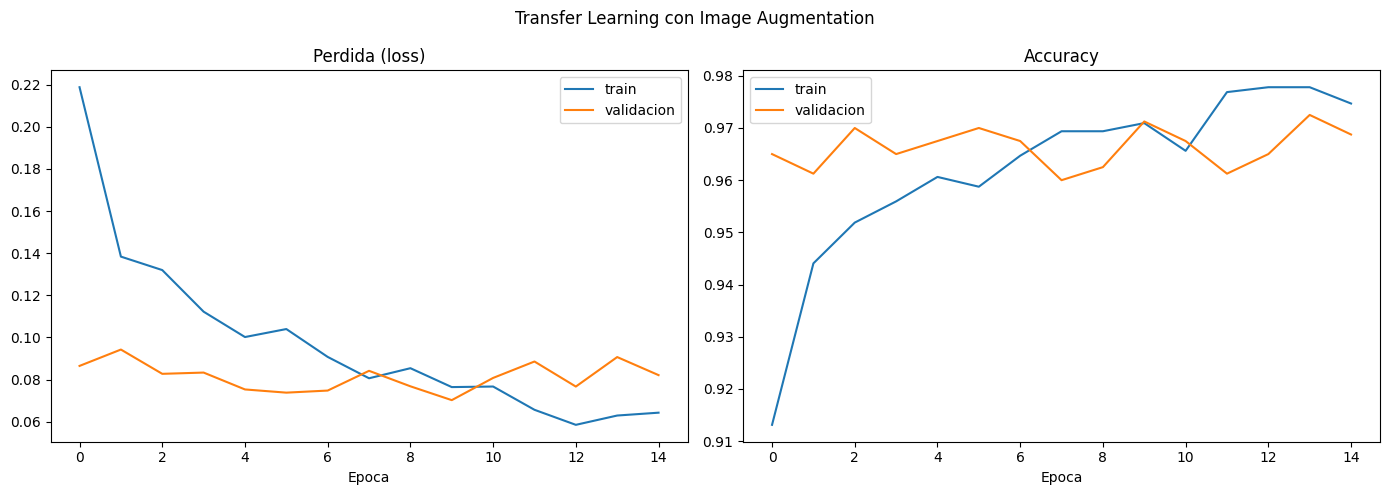

In [23]:
pintar_historial(history_tl_aug, titulo="Transfer Learning con Image Augmentation")

=== Transfer Learning + Augmentation ===
Accuracy en test: 0.966

Classification report

              precision    recall  f1-score   support

        gato       0.96      0.97      0.97       500
       perro       0.97      0.96      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



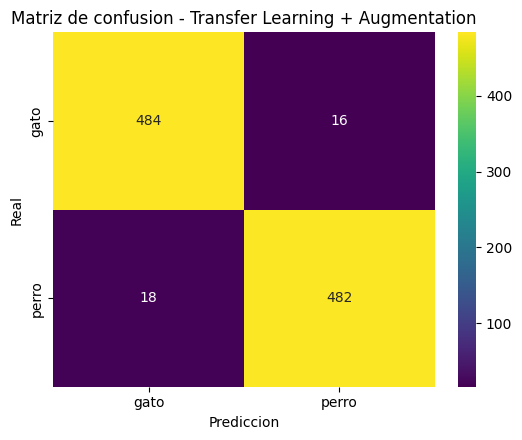

In [24]:
acc_tl_aug, pred_tl_aug, prob_tl_aug = evaluar_modelo(
    modelo_tl_aug, X_test_prep, y_test, titulo="Transfer Learning + Augmentation"
)

In [25]:
# Comparativa final con los cuatro modelos
comparacion_final = pd.DataFrame({
    "modelo": ["CNN ad-hoc", "Transfer Learning", "Fine Tuning", "TL + Augmentation"],
    "accuracy_test": [acc_cnn, acc_tl, acc_ft, acc_tl_aug],
}).round(3).sort_values("accuracy_test", ascending=False).reset_index(drop=True)

comparacion_final

,modelo,accuracy_test
0,TL + Augmentation,0.966
1,Fine Tuning,0.966
2,Transfer Learning,0.957
3,CNN ad-hoc,0.755


**Conclusión final:**

Los modelos preentrenados ganan de calle a la CNN construida desde cero: con pocos datos, aprovechar lo que MobileNetV2 ya aprendió de ImageNet es muchísimo más eficaz que entrenar una red pequeña partiendo de pesos aleatorios. Además entrena más rápido, porque en transfer learning solo se ajusta la cabeza.

El **augmentation** ayuda sobre todo a reducir el sobreajuste (se nota en la separación entre las curvas de train y validación), aunque cuando el transfer learning ya está muy cerca del techo de accuracy, la mejora que aporta es pequeña.